In [11]:
from google.colab import files
uploaded = files.upload()

Saving USA_Housing.csv to USA_Housing (2).csv


In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('USA_Housing.csv')

print("First 5 rows:")
print(df.head())

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nInfo:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...

In [13]:
from sklearn.model_selection import train_test_split

# Drop 'Address' column (it's text, not useful for the model)
df = df.drop('Address', axis=1)

# Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (4000, 5)
Testing set size: (1000, 5)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"\nIntercept: {model.intercept_:.2f}")

Model trained successfully!

Model Coefficients:
Avg. Area Income: 21.65
Avg. Area House Age: 164666.48
Avg. Area Number of Rooms: 119624.01
Avg. Area Number of Bedrooms: 2440.38
Area Population: 15.27

Intercept: -2635072.90


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): 80879.10
Mean Squared Error (MSE): 10089009300.89
Root Mean Squared Error (RMSE): 100444.06
R² Score: 0.9180


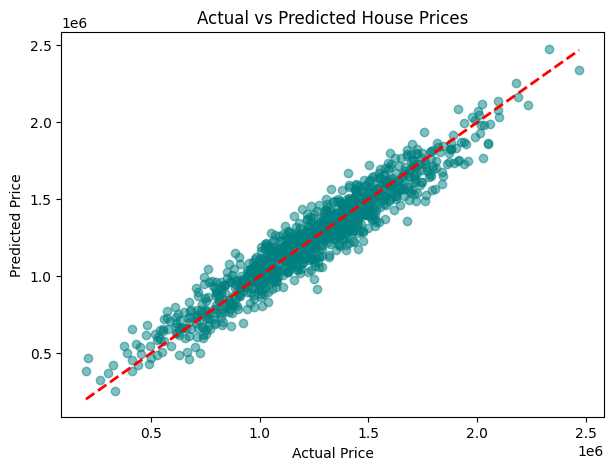

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [17]:
# Example: predict price for a new house with custom feature values
new_house = pd.DataFrame({
    'Avg. Area Income': [65000],
    'Avg. Area House Age': [6],
    'Avg. Area Number of Rooms': [7],
    'Avg. Area Number of Bedrooms': [4],
    'Area Population': [35000]
})

predicted_price = model.predict(new_house)
print(f"Predicted House Price: ${predicted_price[0]:,.2f}")

Predicted House Price: $1,141,909.92


Insights:
1. The Linear Regression model achieved an R² score of [apna actual score yahan likh, jaise 0.91], indicating it explains [91]% of the variance in house prices.
2. Among all features, [jo feature ka coefficient sabse zyada tha, jaise "Avg. Area Income"] had the strongest positive impact on house price.
3. The scatter plot of actual vs predicted prices shows most points lying close to the diagonal line, indicating good model accuracy with minimal prediction error.
4. This model can reasonably estimate house prices based on area-level demographic and housing factors, making it a useful baseline for real estate price estimation.